# n-step Learning

Following **Chapter 7** from *Reinforcement Learning* (edition 2) by Andrew Barto and Richard S. Sutton

### Setup

In [1]:
import math
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.animation import FuncAnimation
from typing import Callable, Any, Optional
from IPython.display import HTML

### Random Walk

In [2]:
class RandomWalkEnv:

    def __init__(self, 
            n_states: int,
            ):
        self.n_states = n_states # including terminal states
        self.s = self.n_states // 2 # start at middle

    def reset(self) -> int:
        self.s = self.n_states // 2
        return self.s

    def step(self, a: int) -> tuple[float, int, bool]:
        reward = 0
        s_prime = self.s + a
        if s_prime == 0: # terminal state on the left
            reward = -1
        if s_prime == self.n_states - 1: # terminal state on the right
            reward = 1
        self.s = s_prime
        finished = (s_prime == self.n_states - 1) or (s_prime == 0)
        return reward, s_prime, finished

In [3]:
def initialize_V_pi(n_states: int) -> np.ndarray:
    return np.zeros(n_states)

def random_walk_stochastic_policy(s: int) -> int:
    p = np.random.random()
    if p < 0.5:
        return 1 # right|
    return -1 # left

def plot_V_pi(V_pi: np.ndarray):
    states = np.arange(len(V_pi))
    plt.figure(figsize=(8, 4))
    plt.plot(states, V_pi, marker='o', linestyle='-', color='tab:blue')
    plt.scatter([0, len(V_pi) - 1], [V_pi[0], V_pi[-1]], color='tab:red', zorder=5)
    plt.xlabel('State')
    plt.ylabel('$V_\pi(s)$')
    plt.title('1D Random Walk State-Value Function')
    plt.xticks(states)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.annotate('left terminal', xy=(0, V_pi[0]), xytext=(1, max(V_pi) * 0.1), arrowprops=dict(arrowstyle='->', color='gray'))
    plt.annotate('right terminal', xy=(len(V_pi) - 1, V_pi[-1]), xytext=(len(V_pi) - 2, max(V_pi) * 0.1), arrowprops=dict(arrowstyle='->', color='gray'))
    plt.show()

In [4]:
n_states = 19
V_pi_gt = np.array([0 if s in (0, n_states - 1) else s / (n_states - 1) for s in range(n_states)])

n_episodes = 100000
n = 5 # n-step return
alpha = 0.1 # step size
gamma = 1.0 # discount factor

### n-step prediction

Let 1 refer to the case where values are unchanging during the n-step backup and 2 refer to the case where they are changing.

In [5]:
def run_sum_of_TD_errors_variant(n_states: int, n_episodes: int, n: int, alpha: float, gamma: float, verbose: bool = True) -> np.ndarray:
    env_1 = RandomWalkEnv(n_states)
    V_pi_1 = initialize_V_pi(n_states)

    for ep_idx in tqdm(range(n_episodes), disable=not verbose):
        V_pi = V_pi_1.copy()

        s = env_1.reset()
        S = [s] # observed states
        R = [] # observed rewards

        while True:
            a = random_walk_stochastic_policy(s)
            r, s_prime, done = env_1.step(a)
            S.append(s_prime)
            R.append(r)
            if done:
                break
        
        T = len(R)
        for t in range(T + n - 1):
            tau = t - n + 1 # tau is the time step being updated
            if tau >= 0:
                # Cumulative rewards from tau+1 to min(tau+n, T)
                G = 0.0
                for i in range(tau + 1, min(tau + n, T) + 1):
                    G += (gamma ** (i - tau - 1 )) * R[i - 1] # R is 0-indexed, so step i is index i-1

                # If the n-step lookahead does not reach the end of the episode, bootstrap
                if tau + n < T:
                    G += (gamma ** n) * V_pi[S[tau + n]]
                if S[tau] not in (0, n_states - 1): # Avoid updating terminal states
                    V_pi[S[tau]] += alpha * (G - V_pi[S[tau]]) # Update

        V_pi_1 = V_pi.copy()

    return V_pi_1

In [6]:
V_pi_1 = run_sum_of_TD_errors_variant(n_states, n_episodes, n, alpha, gamma)

100%|██████████| 100000/100000 [00:21<00:00, 4679.78it/s]


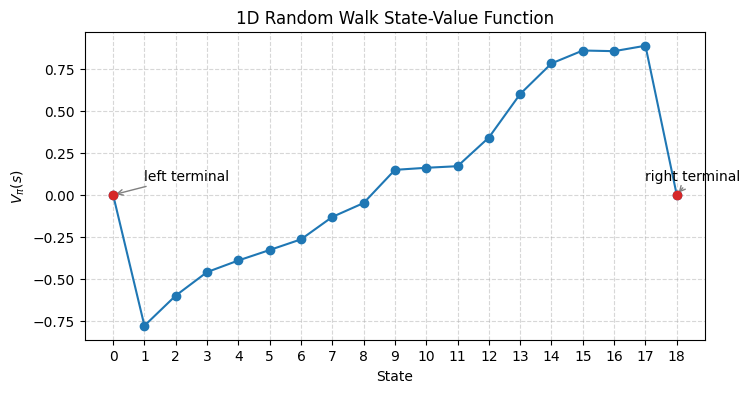

In [7]:
plot_V_pi(V_pi_1)

In [8]:
RMSE_1 = np.sqrt(np.mean((V_pi_gt[1:-1] - V_pi_1[1:-1]) ** 2))
print(f"RMSE - no online updates: {RMSE_1}")

RMSE - no online updates: 0.4730297415750812


In [9]:
# Case 2: State values are updated online

def run_n_step_online_variant(n_states: int, n_episodes: int, n: int, alpha: float, gamma: float, verbose: bool = True) -> np.ndarray:
    env_2 = RandomWalkEnv(n_states)
    V_pi_2 = initialize_V_pi(n_states)

    for ep_idx in tqdm(range(n_episodes), disable=not verbose):
        s = env_2.reset()
        S = [s] # observed states
        R = [] # observed rewards

        T = float('inf')
        t = 0
        while True:
            # Only take actions and step the environment if we haven't reached the end
            if t < T:
                current_s = S[-1] # Fetch the latest state to get the correct action
                a = random_walk_stochastic_policy(current_s)
                r, s_prime, done = env_2.step(a)
                
                S.append(s_prime)
                R.append(r)
                
                if done:
                    T = t + 1
            
            # tau is the time step being updated
            tau = t - n + 1 
            
            if tau >= 0:
                # actual rewards observed along the way
                G = sum(
                    gamma ** (i - tau - 1) * R[i - 1]
                    for i in range(tau + 1, min(tau + n, T) + 1)
                )
                
                # bootstrap the value function of the nth step - as long as it's still before the end of the episode
                if tau + n < T: 
                    G += (gamma ** n) * V_pi_2[S[tau + n]] 
                    
                # Avoid updating terminal states
                if S[tau] not in (0, n_states - 1): 
                    V_pi_2[S[tau]] += alpha * (G - V_pi_2[S[tau]]) # Update
            
            # Break when the state just prior to termination has been updated
            if tau == T - 1:
                break
                
            # Unconditionally advance time
            t += 1
            
    return V_pi_2

In [10]:
V_pi_2 = run_n_step_online_variant(n_states, n_episodes, n, alpha, gamma)

100%|██████████| 100000/100000 [00:27<00:00, 3650.92it/s]


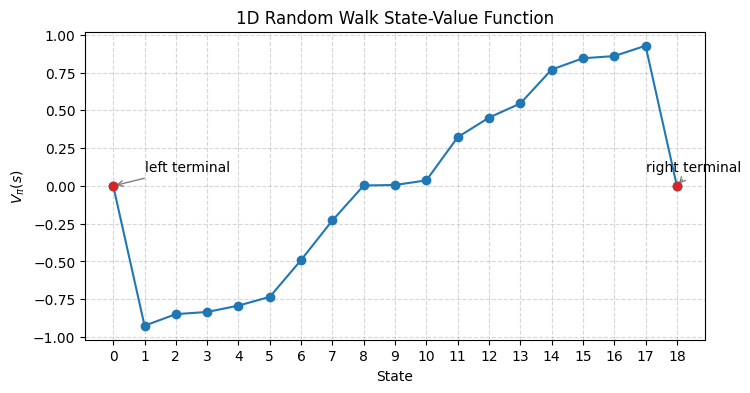

In [11]:
plot_V_pi(V_pi_2)

In [12]:
RMSE_2 = np.sqrt(np.mean((V_pi_gt[1:-1] - V_pi_2[1:-1]) ** 2))
print(f"RMSE - online updates: {RMSE_2}")

RMSE - online updates: 0.6356690409012028


In [13]:
print(f"Comparison:\nCase 1: No step-by-step updates   - RMSE {RMSE_1}\nCase 2: With step-by-step updates - RMSE {RMSE_2}")

Comparison:
Case 1: No step-by-step updates   - RMSE 0.4730297415750812
Case 2: With step-by-step updates - RMSE 0.6356690409012028


In [14]:
n_options = [1, 2, 4, 8, 16, 32]
alpha_options = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

# Book parameters: 100 runs, evaluating across the first 10 episodes
n_runs = 100       # Note: You can reduce this to 20 or 50 if you want it to run faster during debugging
n_episodes = 10    

# Pre-allocate 2D grids for direct plotting (rows = n_steps, columns = alpha)
rmse_sum_td_2d = np.zeros((len(n_options), len(alpha_options)))
rmse_n_step_2d = np.zeros((len(n_options), len(alpha_options)))

# Using tqdm around the outermost loop to safely monitor progress
for i, n in enumerate(tqdm(n_options, desc="Evaluating Steps (n)")):
    for j, alpha in enumerate(alpha_options):
        
        run_errors_sum_td = []
        run_errors_n_step = []
        
        for run in range(n_runs):
            # Run the experiment variant from scratch (internal state zeros out every run)
            avg_rmse_sum_td = np.sqrt(np.mean((V_pi_gt[1:-1] - run_sum_of_TD_errors_variant(n_states, n_episodes, n, alpha, gamma, False)[1:-1]) ** 2))
            avg_rmse_n_step = np.sqrt(np.mean((V_pi_gt[1:-1] - run_n_step_online_variant(n_states, n_episodes, n, alpha, gamma, False)[1:-1]) ** 2))
            
            run_errors_sum_td.append(avg_rmse_sum_td)
            run_errors_n_step.append(avg_rmse_n_step)
            
        # Average the performance over all independent runs
        rmse_sum_td_2d[i, j] = np.mean(run_errors_sum_td)
        rmse_n_step_2d[i, j] = np.mean(run_errors_n_step)

Evaluating Steps (n): 100%|██████████| 6/6 [00:34<00:00,  5.78s/it]


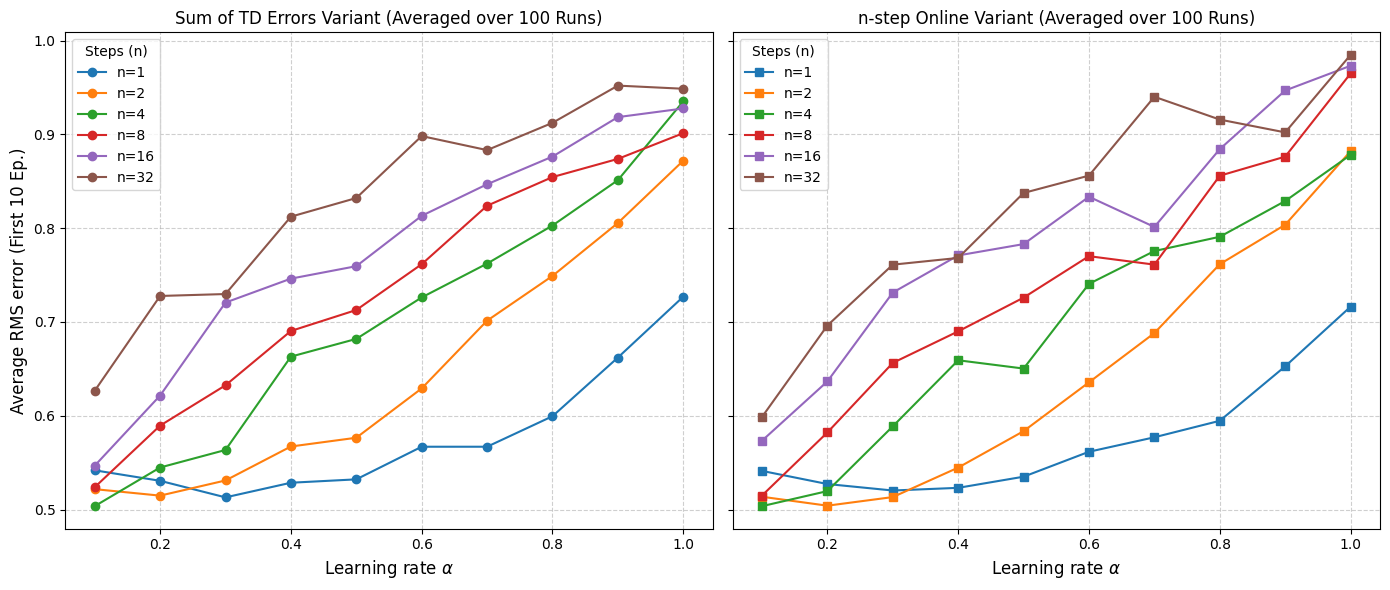

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Plotting Variant 1: Sum of TD Errors
for i, n in enumerate(n_options):
    ax1.plot(alpha_options, rmse_sum_td_2d[i], marker='o', label=f'n={n}')

ax1.set_title('Sum of TD Errors Variant (Averaged over 100 Runs)')
ax1.set_xlabel(r'Learning rate $\alpha$', fontsize=12)
ax1.set_ylabel('Average RMS error (First 10 Ep.)', fontsize=12)
ax1.legend(title='Steps (n)')
ax1.grid(True, linestyle='--', alpha=0.6)

# Plotting Variant 2: n-step Online
for i, n in enumerate(n_options):
    ax2.plot(alpha_options, rmse_n_step_2d[i], marker='s', label=f'n={n}')

ax2.set_title('n-step Online Variant (Averaged over 100 Runs)')
ax2.set_xlabel(r'Learning rate $\alpha$', fontsize=12)
ax2.legend(title='Steps (n)')
ax2.grid(True, linestyle='--', alpha=0.6)

# Adjust y-limits based on your environment's scale (0.55 max is common for random walk error limits)
# ax1.set_ylim([0.0, 0.55]) 

plt.tight_layout()
plt.show()

### n-step SARSA - control

Page *145*, chapter *7.2*

In [16]:
def initialize_Q_pi(n_states: int) -> np.ndarray:
    return np.zeros((n_states, 2))

def epsilon_greedy_pi(s: int, Q_pi: np.ndarray, epsilon: float, action_set: list = [-1, 1]) -> int:
    p = np.random.random()
    if p <= epsilon: # explore
        a_idx = np.random.randint(0, len(action_set))
    else:
        a_idx = np.argmax(Q_pi[s]) 
    a = action_set[a_idx]
    return a

In [17]:
def plot_learned_Q_and_policy(Q_pi: np.ndarray, action_set: list = [-1, 1]) -> None:
    n_states = Q_pi.shape[0]
    greedy_action_idx = np.argmax(Q_pi, axis=1)
    greedy_actions = np.array([action_set[i] for i in greedy_action_idx])
    state_values = np.max(Q_pi, axis=1)

    states = np.arange(n_states)
    fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(10, 7), sharex=True,
                                   gridspec_kw={'height_ratios': [2, 1]})

    ax0.plot(states, Q_pi[:, 0], marker='o', label='Q(s, left)')
    ax0.plot(states, Q_pi[:, 1], marker='s', label='Q(s, right)')
    ax0.plot(states, state_values, linestyle='--', color='gray', label='V(s) = max_a Q(s,a)')
    ax0.set_ylabel('Value')
    ax0.set_title('Learned Action-Value Function and Derived State Values')
    ax0.legend(loc='upper left')
    ax0.grid(True, linestyle='--', alpha=0.5)

    action_symbols = np.where(greedy_actions == -1, '←', '→')
    ax1.scatter(states, greedy_action_idx, c=greedy_action_idx, cmap='viridis', s=80)
    for i, symbol in enumerate(action_symbols):
        ax1.text(i, greedy_action_idx[i], symbol, ha='center', va='bottom', fontsize=10)

    ax1.set_ylim(-0.5, 1.5)
    ax1.set_yticks([0, 1])
    ax1.set_yticklabels(['←', '→'])
    ax1.set_xlabel('State')
    ax1.set_title('Greedy Policy Derived from Learned Q(s, a)')
    ax1.grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()


In [18]:
def run_n_step_SARSA(n_states: int, n_episodes: int, n: int, alpha: float, gamma: float, epsilon: float, verbose: bool = True) -> np.ndarray:
    env = RandomWalkEnv(n_states)
    Q_pi = initialize_Q_pi(n_states)
    action_2_idx = {-1: 0, 1: 1}

    for ep_idx in tqdm(range(n_episodes), disable=not verbose):
        s_0 = env.reset()
        a_0 = epsilon_greedy_pi(s_0, Q_pi, epsilon)
        S = [s_0] # observed states
        A = [a_0] # observed actions
        R = [] # observed rewards

        T = float('inf')
        t = 0
        while True:
            # Only take actions and step the environment if we haven't reached the end
            if t < T:
                current_a = A[-1] # Fetch the latest action
                r, s_prime, done = env.step(current_a)
                
                S.append(s_prime)
                R.append(r)
                
                if done:
                    T = t + 1
                else:
                    a_prime = epsilon_greedy_pi(s_prime, Q_pi, epsilon) # Select next action (without executing)
                    A.append(a_prime) # Store next action
            
            # tau is the time step being updated
            tau = t - n + 1 
            if tau >= 0:
                # actual rewards observed along the way
                G = sum(
                    gamma ** (i - tau - 1) * R[i - 1]
                    for i in range(tau + 1, int(min(tau + n, T)) + 1)
                )
                
                # bootstrap the action-value function of the nth step - as long as it's still before the end of the episode
                if tau + n < T: 
                    G += (gamma ** n) * Q_pi[S[tau + n]][action_2_idx[A[tau + n]]]
                    
                # Avoid updating terminal states
                if S[tau] not in (0, n_states - 1): 
                    Q_pi[S[tau]][action_2_idx[A[tau]]] += alpha * (G - Q_pi[S[tau]][action_2_idx[A[tau]]]) # Update
            
            # Break when the state just prior to termination has been updated
            if tau == T - 1:
                break
                
            # Unconditionally advance time
            t += 1
            
    return Q_pi

In [19]:
Q_pi = run_n_step_SARSA(n_states=15, n_episodes=500_000, n=6, alpha=0.1, gamma=1.0, epsilon=0.2)

100%|██████████| 500000/500000 [01:31<00:00, 5483.27it/s] 


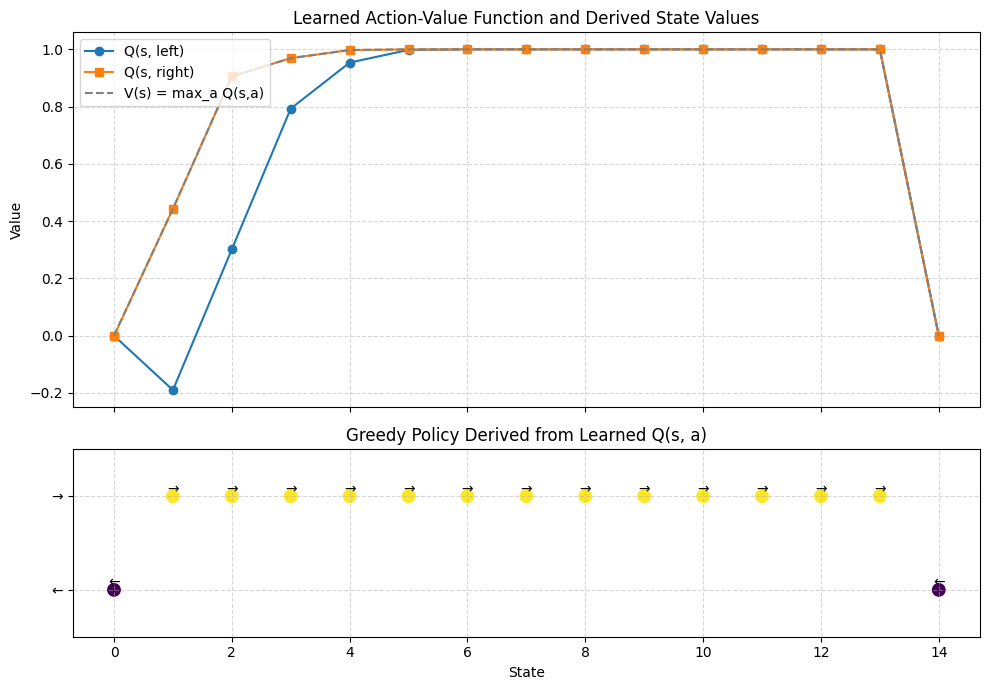

In [20]:
plot_learned_Q_and_policy(Q_pi)

### n-Step Off-policy Learning

Page *148*, chapter *7.3*

In [2]:
from util.envs import WindyGridWorldEnv


def initialize_Q_pi(env: WindyGridWorldEnv, actions: list[tuple[int, int]]):
    Q = {}
    for row in range(env.num_rows):
        for col in range(env.num_cols):
            s = (row, col)
            if s == env.goal_position:
                Q[s] = np.zeros(len(actions)) # zeros Q(terminal, all_a)
                continue
            Q[s] = -np.random.random(len(actions)) # arbitrary Q(s, a)
    return Q

def pi_epsilon_greedy(s: tuple[int, int], Q_pi: dict | tuple[dict, dict], epsilon: float) -> int:
    p = np.random.random()
    
    if isinstance(Q_pi, dict): # Regular
        Q_pi_s = Q_pi[s]
    elif isinstance(Q_pi, tuple): # Double learning
        Q_pi_s = Q_pi[0][s] + Q_pi[1][s] # action via addition from the 2 value functions

    if p < epsilon: # explore
        return int(np.random.randint(len(Q_pi_s)))
    return int(np.argmax(Q_pi_s)) # exploit

def get_pi_prob(s: tuple[int, int], a_idx: int, Q_pi: dict | tuple[dict, dict], epsilon: float) -> float:
    if isinstance(Q_pi, dict):
        q_values = Q_pi[s]
    else:
        q_values = Q_pi[0][s] + Q_pi[1][s]

    n_actions = len(q_values)
    if not (0 <= a_idx < n_actions):
        raise IndexError("a_idx is out of bounds for the action space")

    greedy_action_idx = int(np.argmax(q_values))
    prob = epsilon / n_actions
    if a_idx == greedy_action_idx:
        prob += 1 - epsilon
    return prob

In [3]:
actions = [
    (-1, -1), (-1, 0), (-1, 1), # up-left, straight-top, up-right
    (0, -1), (0, 0), (0, 1), # straight-left, stay, straight-right
    (1, -1), (1, 0), (1, 1), # down-left, straight-down, down-right
]
actions_without_stay = actions[:4] + actions[5:] # excludes (0, 0)

grid_shape = (7, 10)
goal_position = (3, 7)
start_position = (3, 0)
wind_per_column = [0, 0, 0, 1, 1, 1, 2, 2, 1, 0]

windy_env = WindyGridWorldEnv(grid_shape, goal_position, start_position, wind_per_column, False)

In [4]:
def run_n_step_off_policy(env: WindyGridWorldEnv, actions: list, n_episodes: int, n: int, alpha: float, gamma: float, verbose: bool = True) -> dict:
    Q_pi = initialize_Q_pi(env, actions)

    for ep_idx in tqdm(range(n_episodes), disable=not verbose):
        epsilon = 1 / (ep_idx + 1) # decaying epsilon
        s_0 = env.reset()
        a_0 = pi_epsilon_greedy(s_0, Q_pi, epsilon) # Select action via behaviour policy b - in this case, epsilon-greedy

        S = [s_0] # observed states
        A = [a_0] # observed actions
        R = [] # observed rewards
        RHO = [] # importance sampling ratio per action for observed actions

        T = float('inf')
        t = 0
        while True:
            # Only take actions and step the environment if we haven't reached the end
            if t < T:
                a_idx = A[-1] # Fetch the latest action
                a = actions[a_idx]
                r, s_prime, done = env.step(a)

                # calculate importance sampling ratio
                p_pi = get_pi_prob(S[-1], a_idx, Q_pi, 0) # probability under target policy (greedy - epsilon 0)
                p_b = get_pi_prob(S[-1], a_idx, Q_pi, epsilon) # probability under behavior policy (epsilon-greedy)
                rho = p_pi / p_b
                RHO.append(rho)
                
                S.append(s_prime)
                R.append(r)
                
                if done:
                    T = t + 1
                else:
                    a_prime_idx = pi_epsilon_greedy(s_prime, Q_pi, epsilon) # Select next action (without executing) via behaviour policy b - in this case, epsilon-greedy
                    A.append(a_prime_idx) # Store next action index
            
            # tau is the time step being updated
            tau = t - n + 1 
            if tau >= 0:
                rho = math.prod(RHO[tau+1:min(tau+n,T-1)]) # importance sampling ratio for trajectory
                # actual rewards observed along the way
                G = sum(
                    gamma ** (i - tau - 1) * R[i - 1]
                    for i in range(tau + 1, int(min(tau + n, T)) + 1)
                )
                
                # bootstrap the action-value function of the nth step - as long as it's still before the end of the episode
                if tau + n < T: 
                    G += gamma ** n * Q_pi[S[tau+n]][A[tau+n]]
                    
                # Avoid updating terminal states
                if S[tau] != env.goal_position:
                    Q_pi[S[tau]][A[tau]] += alpha * rho * (G - Q_pi[S[tau]][A[tau]]) # Update
            
            # Break when the state just prior to termination has been updated
            if tau == T - 1:
                break
                
            # Unconditionally advance time
            t += 1
            
    return Q_pi

In [5]:
gamma = 0.9 # discount factor
alpha = 0.5 # step size
n_episodes = 10000
n = 5 # n-step parameter
use_stay_action = False
action_set = actions if use_stay_action else actions_without_stay

Q_pi = run_n_step_off_policy(windy_env, action_set, n_episodes, n, alpha, gamma, True)

  0%|          | 0/10000 [00:00<?, ?it/s]

100%|██████████| 10000/10000 [00:34<00:00, 291.70it/s]


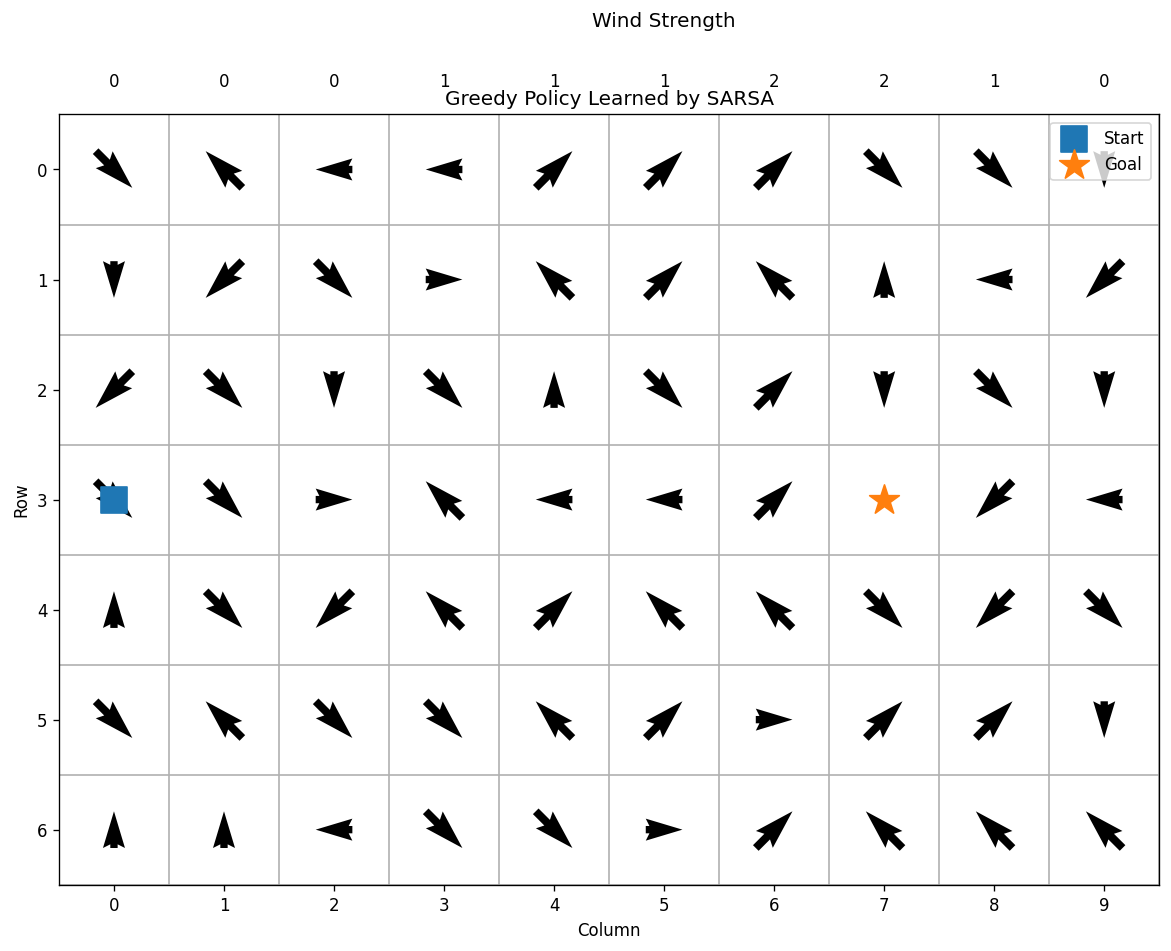

In [6]:
windy_env.plot_policy(Q_pi, action_set)

In [7]:
windy_env.animate_episode_with_trail(Q_pi, action_set)